In [65]:
import glob
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from models.MLP import MLP

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)


In [66]:
csv_paths = sorted(glob.glob("runs/*.csv"))
if not csv_paths:
    raise FileNotFoundError("No run CSVs found in runs/*.csv")

frames = []
for p in csv_paths:
    df = pd.read_csv(p)
    df["source_csv"] = os.path.basename(p)
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

numeric_cols = [
    "epoch", "train_loss", "train_acc", "val_loss", "val_acc",
    "best_val_acc_so_far", "best_epoch_so_far", "lr_current", "test_acc",
    "dropout", "lr", "step_size", "gamma", "tmax", "weight_decay",
    "l1_lambda", "batch_size", "epochs", "use_bn", "seed"
]
for c in numeric_cols:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors="coerce")

all_df.head()


,run_name,seed,hidden_sizes,activation,dropout,use_bn,bn_position,lr,scheduler,step_size,...,train_loss,train_acc,val_loss,val_acc,best_val_acc_so_far,best_epoch_so_far,lr_current,test_acc,test_per_class,source_csv
0,A1_depth1_w256,42,256,relu,0.3,1,pre,0.001,step,5,...,0.266498,0.923683,0.127312,0.9628,0.9628,1.0,0.001,NaN,NaN,A1_depth1_w256.csv
1,A1_depth1_w256,42,256,relu,0.3,1,pre,0.001,step,5,...,0.146616,0.956517,0.098400,0.9692,0.9692,2.0,0.001,NaN,NaN,A1_depth1_w256.csv
2,A1_depth1_w256,42,256,relu,0.3,1,pre,0.001,step,5,...,0.116924,0.964567,0.084360,0.9753,0.9753,3.0,0.001,NaN,NaN,A1_depth1_w256.csv
3,A1_depth1_w256,42,256,relu,0.3,1,pre,0.001,step,5,...,0.099596,0.969500,0.075711,0.9769,0.9769,4.0,0.001,NaN,NaN,A1_depth1_w256.csv
4,A1_depth1_w256,42,256,relu,0.3,1,pre,0.001,step,5,...,0.086510,0.974350,0.073891,0.9765,0.9769,4.0,0.001,NaN,NaN,A1_depth1_w256.csv


In [67]:
epoch_df = all_df[all_df["epoch"] >= 0].copy()
test_df = all_df[all_df["epoch"] == -1][["run_name", "test_acc", "test_per_class"]].copy()
test_df = test_df.drop_duplicates(subset=["run_name"], keep="last")

best_val = epoch_df.groupby("run_name", as_index=False)["best_val_acc_so_far"].max()

hyper_cols = [
    "run_name", "hidden_sizes", "activation", "dropout", "use_bn",
    "bn_position", "lr", "scheduler", "step_size", "gamma", "tmax",
    "weight_decay", "l1_lambda", "batch_size", "epochs", "seed"
]
run_hparams = all_df[hyper_cols].drop_duplicates(subset=["run_name"], keep="last")

final_scores = best_val.merge(test_df, on="run_name", how="left")
final_scores = final_scores.merge(run_hparams, on="run_name", how="left")
final_scores["final_metric"] = final_scores["test_acc"].where(
    final_scores["test_acc"].notna(), final_scores["best_val_acc_so_far"]
)

final_scores.sort_values("final_metric", ascending=False).head(10)


,run_name,best_val_acc_so_far,test_acc,test_per_class,hidden_sizes,activation,dropout,use_bn,bn_position,lr,scheduler,step_size,gamma,tmax,weight_decay,l1_lambda,batch_size,epochs,seed,final_metric
25,best_cfg_cosine,0.9890,0.9890,"0.994898,0.994714,0.988372,0.988119,0.983707,0...","512,256,128",relu,0.1,1,pre,0.001,cosine,5,0.5,10,0.0001,0.00000,64,20,42,0.9890
15,D6_sched_cosine,0.9868,0.9868,"0.991837,0.996476,0.987403,0.986139,0.986762,0...","512,256,128",relu,0.3,1,pre,0.001,cosine,5,0.5,10,0.0001,0.00000,64,10,42,0.9868
10,C2_drop_0p1,0.9853,0.9853,"0.991837,0.996476,0.986434,0.985149,0.976578,0...","512,256,128",relu,0.1,1,pre,0.001,step,5,0.5,10,0.0001,0.00000,64,10,42,0.9853
20,F3_l2_1e-4,0.9853,0.9853,"0.993878,0.991189,0.987403,0.985149,0.978615,0...","512,256,128",relu,0.3,1,pre,0.001,step,5,0.5,10,0.0001,0.00000,64,10,42,0.9853
6,B0_baseline,0.9853,0.9853,"0.993878,0.991189,0.987403,0.985149,0.978615,0...","512,256,128",relu,0.3,1,pre,0.001,step,5,0.5,10,0.0001,0.00000,64,10,42,0.9853
5,A6_depth3_w512,0.9848,0.9848,"0.990816,0.995595,0.984496,0.991089,0.985743,0...","512,512,512",relu,0.3,1,pre,0.001,step,5,0.5,10,0.0001,0.00000,64,10,42,0.9848
3,A4_depth4_w256,0.9846,0.9846,"0.991837,0.992070,0.980620,0.986139,0.986762,0...","256,256,256,256",relu,0.3,1,pre,0.001,step,5,0.5,10,0.0001,0.00000,64,10,42,0.9846
7,B2_act_gelu,0.9845,0.9845,"0.992857,0.996476,0.981589,0.986139,0.971487,0...","512,256,128",gelu,0.3,1,pre,0.001,step,5,0.5,10,0.0001,0.00000,64,10,42,0.9845
23,F6_l1_1e-5,0.9845,0.9845,"0.991837,0.992070,0.986434,0.989109,0.991853,0...","512,256,128",relu,0.3,1,pre,0.001,step,5,0.5,10,0.0000,0.00001,64,10,42,0.9845
1,A2_depth2_w256,0.9844,0.9844,"0.994898,0.990308,0.986434,0.980198,0.977597,0...","256,256",relu,0.3,1,pre,0.001,step,5,0.5,10,0.0001,0.00000,64,10,42,0.9844


In [68]:
# Helper utilities for plots and parsing
def parse_hidden_sizes_str(s):
    return [int(x) for x in str(s).split(",") if str(x).strip()]

def compute_param_count(row):
    # MLP params: Linear layers + (optional) BN params (gamma,beta) per hidden unit
    hs = parse_hidden_sizes_str(row["hidden_sizes"])
    dims = [784] + hs + [10]
    linear = 0
    for a,b in zip(dims[:-1], dims[1:]):
        linear += (a + 1) * b  # weights + bias
    bn = 0
    if int(row.get("use_bn", 0)) == 1:
        for h in hs:
            bn += 2 * h
    return int(linear + bn)

def zoom_ylim(ax, values, pad=0.002):
    values = np.asarray(values, dtype=float)
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return
    lo = vmin - pad
    hi = vmax + pad
    ax.set_ylim(lo, hi)

def add_bar_labels(ax, bars, fmt="{:.4f}"):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, fmt.format(h), ha="center", va="bottom", fontsize=9)


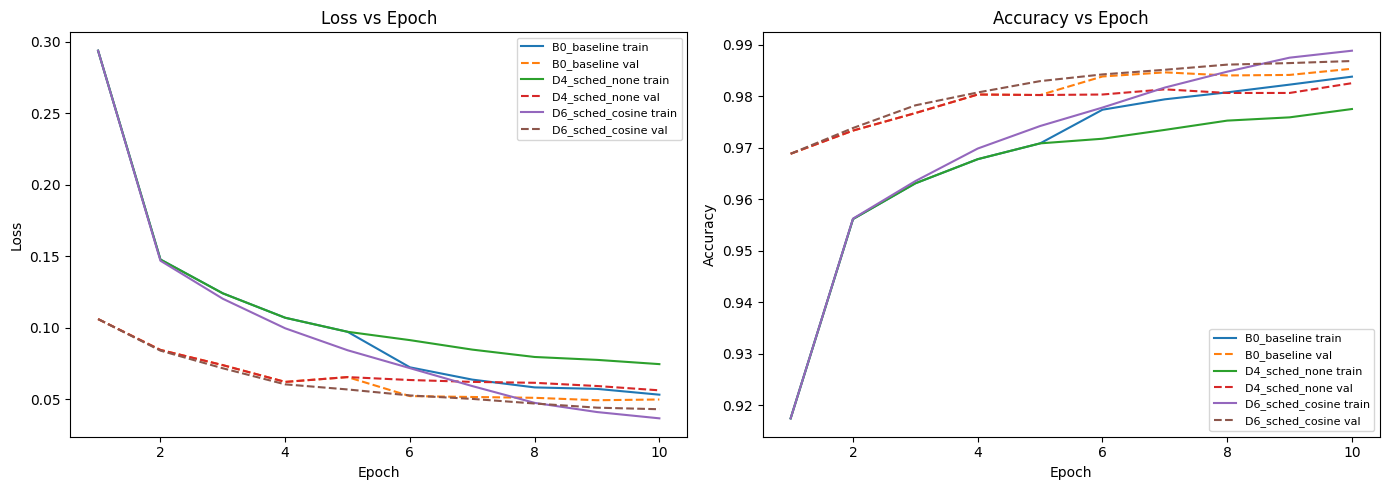

In [69]:
# Training framework: baseline (step) + scheduler comparison
selected_runs = ["B0_baseline", "D4_sched_none", "D6_sched_cosine"]
plot_df = epoch_df[epoch_df["run_name"].isin(selected_runs)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for rn in selected_runs:
    d = plot_df[plot_df["run_name"] == rn].sort_values("epoch")
    if d.empty:
        continue
    axes[0].plot(d["epoch"], d["train_loss"], label=f"{rn} train")
    axes[0].plot(d["epoch"], d["val_loss"], linestyle="--", label=f"{rn} val")
    axes[1].plot(d["epoch"], d["train_acc"], label=f"{rn} train")
    axes[1].plot(d["epoch"], d["val_acc"], linestyle="--", label=f"{rn} val")

axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


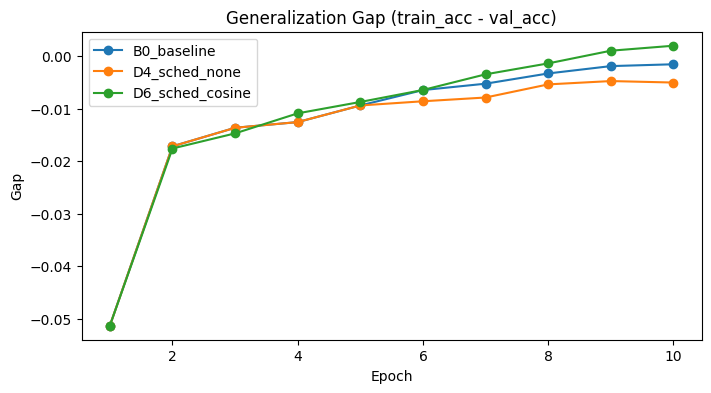

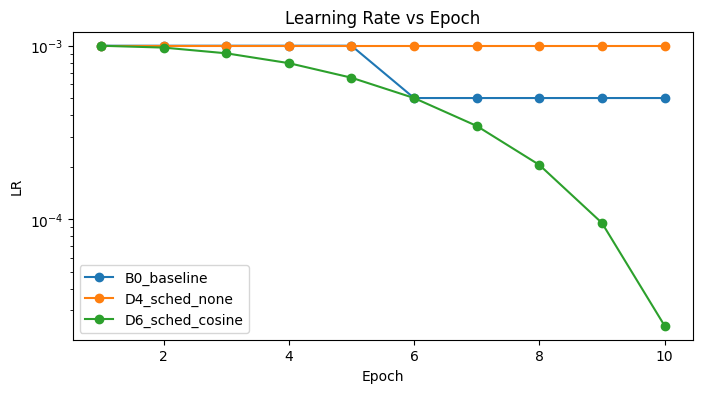

In [70]:
# Training diagnostics: generalization gap + learning-rate curves
selected_runs = ["B0_baseline", "D4_sched_none", "D6_sched_cosine"]
d = epoch_df[epoch_df["run_name"].isin(selected_runs)].copy()

# Generalization gap (train_acc - val_acc)
plt.figure(figsize=(8,4))
for rn in selected_runs:
    r = d[d["run_name"]==rn].sort_values("epoch")
    if r.empty:
        continue
    gap = r["train_acc"] - r["val_acc"]
    plt.plot(r["epoch"], gap, marker="o", label=rn)
plt.title("Generalization Gap (train_acc - val_acc)")
plt.xlabel("Epoch")
plt.ylabel("Gap")
plt.legend()
plt.show()

# Learning rate over epochs (if available)
if "lr_current" in d.columns and d["lr_current"].notna().any():
    plt.figure(figsize=(8,4))
    for rn in selected_runs:
        r = d[d["run_name"]==rn].sort_values("epoch")
        if r.empty:
            continue
        plt.plot(r["epoch"], r["lr_current"], marker="o", label=rn)
    plt.title("Learning Rate vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.yscale("log")
    plt.legend()
    plt.show()
else:
    print("lr_current not available in logs.")


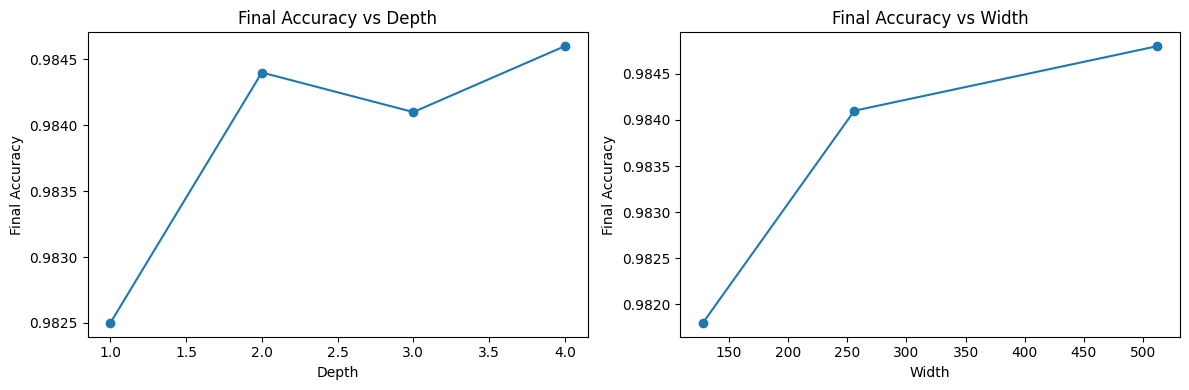

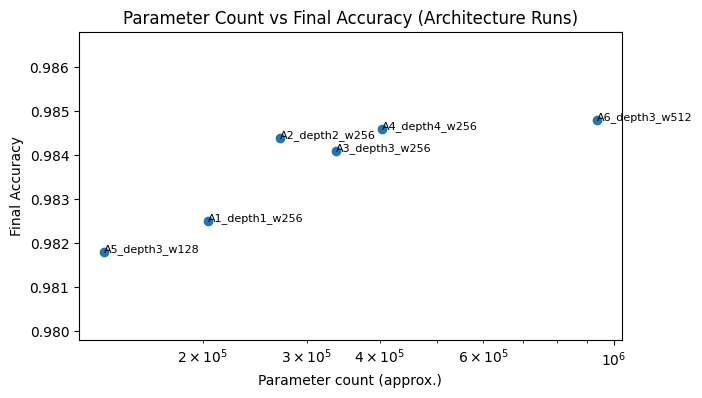

In [71]:
# Architecture impact: depth and width plots
a_depth_runs = ["A1_depth1_w256", "A2_depth2_w256", "A3_depth3_w256", "A4_depth4_w256"]
a_width_runs = ["A5_depth3_w128", "A3_depth3_w256", "A6_depth3_w512"]

arch_depth = final_scores[final_scores["run_name"].isin(a_depth_runs)].copy()
arch_depth["depth"] = arch_depth["hidden_sizes"].astype(str).str.split(",").map(len)
arch_depth = arch_depth.sort_values("depth")

arch_width = final_scores[final_scores["run_name"].isin(a_width_runs)].copy()
arch_width["width"] = arch_width["hidden_sizes"].astype(str).str.split(",").map(lambda x: int(x[0]))
arch_width = arch_width.sort_values("width")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(arch_depth["depth"], arch_depth["final_metric"], marker="o")
axes[0].set_title("Final Accuracy vs Depth")
axes[0].set_xlabel("Depth")
axes[0].set_ylabel("Final Accuracy")

axes[1].plot(arch_width["width"], arch_width["final_metric"], marker="o")
axes[1].set_title("Final Accuracy vs Width")
axes[1].set_xlabel("Width")
axes[1].set_ylabel("Final Accuracy")

plt.tight_layout()
plt.show()


# Capacity view: parameter count vs final accuracy (architecture runs)
arch_runs = ["A1_depth1_w256", "A2_depth2_w256", "A3_depth3_w256", "A4_depth4_w256", "A5_depth3_w128", "A6_depth3_w512"]
cap_df = final_scores[final_scores["run_name"].isin(arch_runs)].copy()
cap_df["param_count"] = cap_df.apply(compute_param_count, axis=1)

plt.figure(figsize=(7,4))
plt.scatter(cap_df["param_count"], cap_df["final_metric"])
for _, r in cap_df.iterrows():
    plt.text(r["param_count"], r["final_metric"], r["run_name"], fontsize=8)
plt.title("Parameter Count vs Final Accuracy (Architecture Runs)")
plt.xlabel("Parameter count (approx.)")
plt.ylabel("Final Accuracy")
ax = plt.gca()
zoom_ylim(ax, cap_df["final_metric"].values, pad=0.002)
plt.xscale("log")
plt.show()


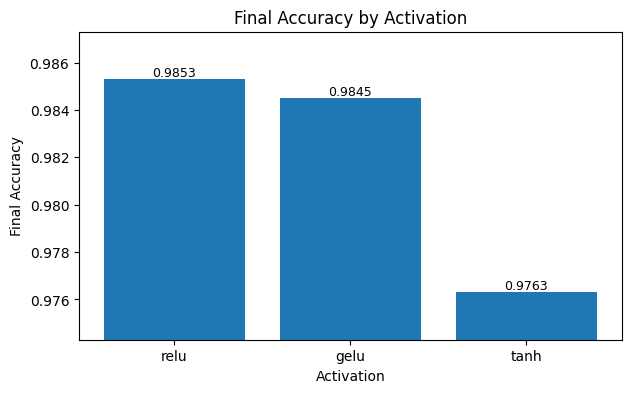

In [72]:
# Activation impact
act_runs = ["B0_baseline", "B2_act_gelu", "B3_act_tanh"]
act_df = final_scores[final_scores["run_name"].isin(act_runs)].copy()
act_df["activation"] = act_df["activation"].astype(str)

plt.figure(figsize=(7, 4))
bars = plt.bar(act_df["activation"], act_df["final_metric"])
plt.title("Final Accuracy by Activation")
plt.xlabel("Activation")
plt.ylabel("Final Accuracy")
ax = plt.gca()
zoom_ylim(ax, act_df["final_metric"].values, pad=0.002)
add_bar_labels(ax, bars, fmt="{:.4f}")
plt.show()


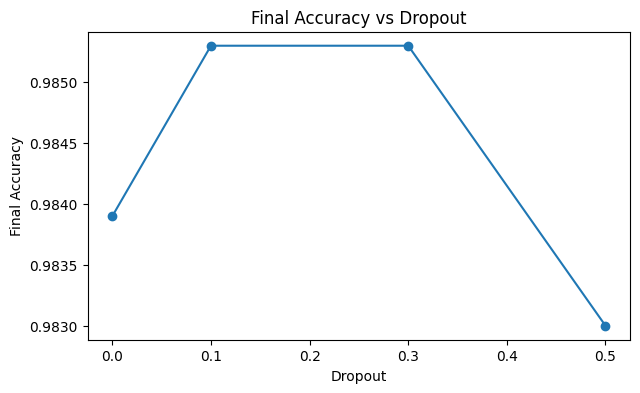

In [73]:
# Dropout impact
drop_runs = ["C1_drop_0p0", "C2_drop_0p1", "B0_baseline", "C4_drop_0p5"]
drop_df = final_scores[final_scores["run_name"].isin(drop_runs)].copy()
drop_df = drop_df.sort_values("dropout")

plt.figure(figsize=(7, 4))
plt.plot(drop_df["dropout"], drop_df["final_metric"], marker="o")
plt.title("Final Accuracy vs Dropout")
plt.xlabel("Dropout")
plt.ylabel("Final Accuracy")
plt.show()


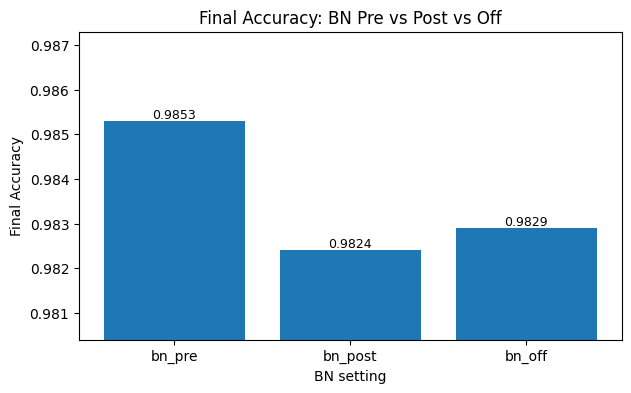

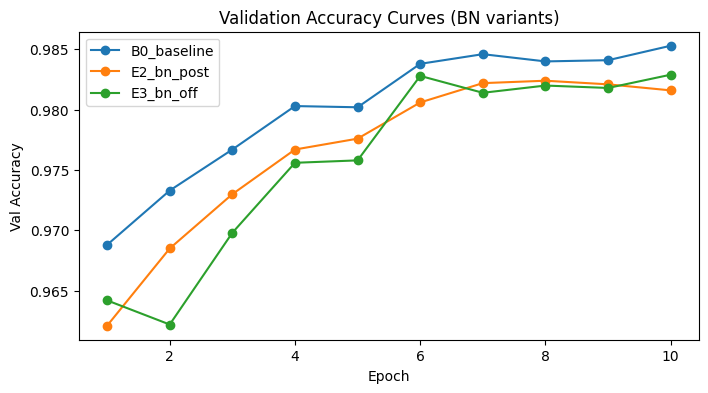

In [74]:
# BatchNorm impact
bn_runs = ["B0_baseline", "E2_bn_post", "E3_bn_off"]
bn_df = final_scores[final_scores["run_name"].isin(bn_runs)].copy()

def bn_label(r):
    if int(r["use_bn"]) == 0:
        return "bn_off"
    return f"bn_{r['bn_position']}"

bn_df["bn_setting"] = bn_df.apply(bn_label, axis=1)
order = ["bn_pre", "bn_post", "bn_off"]
bn_df["bn_setting"] = pd.Categorical(bn_df["bn_setting"], categories=order, ordered=True)
bn_df = bn_df.sort_values("bn_setting")

plt.figure(figsize=(7, 4))
bars = plt.bar(bn_df["bn_setting"].astype(str), bn_df["final_metric"])
plt.title("Final Accuracy: BN Pre vs Post vs Off")
plt.xlabel("BN setting")
plt.ylabel("Final Accuracy")
ax = plt.gca()
zoom_ylim(ax, bn_df["final_metric"].values, pad=0.002)
add_bar_labels(ax, bars, fmt="{:.4f}")
plt.show()

# Val accuracy curves for BN variants
bn_curve_df = epoch_df[epoch_df["run_name"].isin(bn_runs)].copy()
plt.figure(figsize=(8, 4))
for rn in bn_runs:
    d = bn_curve_df[bn_curve_df["run_name"] == rn].sort_values("epoch")
    if not d.empty:
        plt.plot(d["epoch"], d["val_acc"], marker="o", label=rn)
plt.title("Validation Accuracy Curves (BN variants)")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()


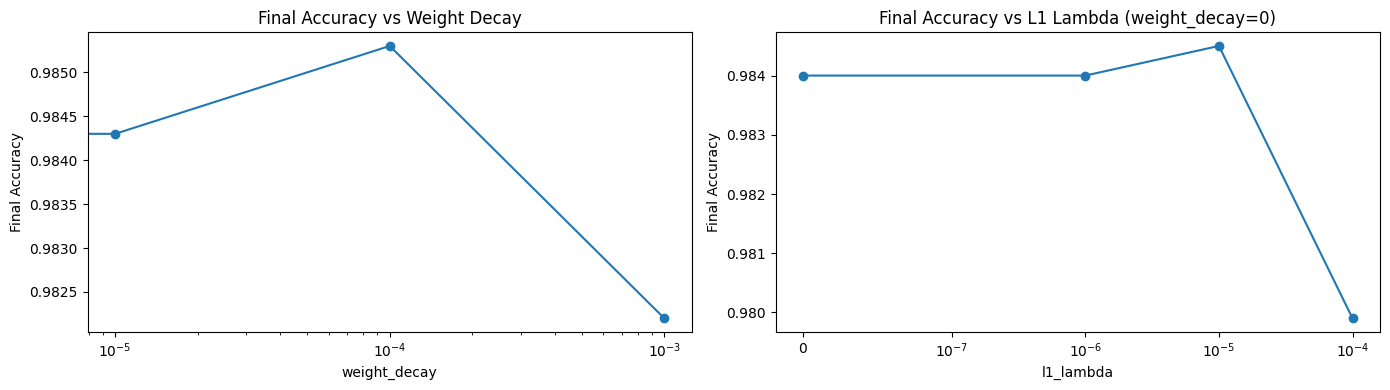

In [75]:
# Regularization impact
l2_runs = ["F1_l2_0", "F2_l2_1e-5", "F3_l2_1e-4", "F4_l2_1e-3"]
l2_df = final_scores[final_scores["run_name"].isin(l2_runs)].copy().sort_values("weight_decay")

l1_runs = ["F1_l2_0", "F5_l1_1e-6", "F6_l1_1e-5", "F7_l1_1e-4"]
l1_df = final_scores[final_scores["run_name"].isin(l1_runs)].copy().sort_values("l1_lambda")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(l2_df["weight_decay"], l2_df["final_metric"], marker="o")
axes[0].set_xscale("log")
axes[0].set_title("Final Accuracy vs Weight Decay")
axes[0].set_xlabel("weight_decay")
axes[0].set_ylabel("Final Accuracy")

axes[1].plot(l1_df["l1_lambda"], l1_df["final_metric"], marker="o")
axes[1].set_xscale("symlog", linthresh=1e-7)
axes[1].set_title("Final Accuracy vs L1 Lambda (weight_decay=0)")
axes[1].set_xlabel("l1_lambda")
axes[1].set_ylabel("Final Accuracy")

plt.tight_layout()
plt.show()


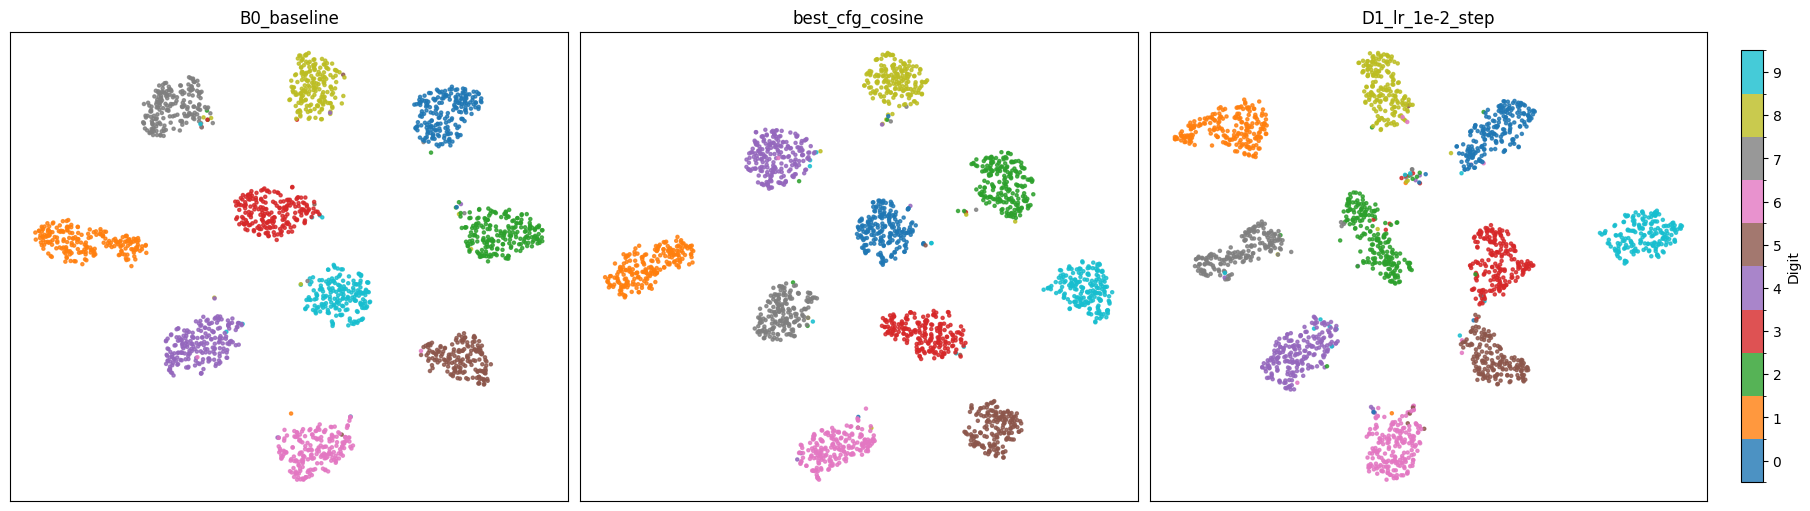

In [76]:
# t-SNE on representative models (baseline, best, worst)
import matplotlib.colors as mcolors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ranked = final_scores.dropna(subset=["final_metric"]).sort_values("final_metric", ascending=False)
if ranked.empty:
    raise ValueError("No scored runs available for t-SNE")

best_run = ranked.iloc[0]["run_name"]
worst_run = ranked.iloc[-1]["run_name"]
rep_runs = []
for rn in ["B0_baseline", best_run, worst_run]:
    if rn not in rep_runs:
        rep_runs.append(rn)


def parse_hidden_sizes(s):
    return [int(x) for x in str(s).split(",") if x]


def build_model_from_run(run_name):
    row = run_hparams[run_hparams["run_name"] == run_name].iloc[0]
    model = MLP(
        input_size=784,
        hidden_sizes=parse_hidden_sizes(row["hidden_sizes"]),
        num_classes=10,
        dropout=float(row["dropout"]),
        activation=str(row["activation"]),
        use_bn=int(row["use_bn"]),
        bn_position=str(row["bn_position"]),
    )
    ckpt = f"runs/{run_name}.pth"
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval().to(device)
    return model


def extract_penultimate_embeddings(model, loader):
    all_embeddings = []
    all_labels = []
    cache = []

    def hook(_, __, output):
        cache.append(output.detach())

    handle = model.net[-2].register_forward_hook(hook)
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            cache.clear()
            _ = model(imgs)
            emb = cache[0].view(cache[0].size(0), -1).cpu()
            all_embeddings.append(emb)
            all_labels.append(labels)
    handle.remove()

    X = torch.cat(all_embeddings).numpy()
    y = torch.cat(all_labels).numpy()
    return X, y


tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
test_ds = datasets.MNIST("./data", train=False, download=True, transform=tf)
indices = np.random.RandomState(42).choice(len(test_ds), size=min(2000, len(test_ds)), replace=False)
subset_loader = DataLoader(Subset(test_ds, indices), batch_size=256, shuffle=False)

fig, axes = plt.subplots(1, len(rep_runs), figsize=(6 * len(rep_runs), 5), constrained_layout=True)
if len(rep_runs) == 1:
    axes = [axes]
else:
    axes = np.array(axes).ravel().tolist()

# Use a discrete colormap/norm so colorbar aligns exactly with class labels 0..9
cmap = plt.get_cmap("tab10", 10)
norm = mcolors.BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)
sc = None

for ax, run_name in zip(axes, rep_runs):
    ckpt_path = f"runs/{run_name}.pth"
    if not os.path.exists(ckpt_path):
        ax.set_title(f"{run_name} missing checkpoint")
        ax.axis("off")
        continue

    model = build_model_from_run(run_name)
    X, y = extract_penultimate_embeddings(model, subset_loader)
    Z = TSNE(n_components=2, random_state=42, init="random", learning_rate="auto", perplexity=30).fit_transform(X)

    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap=cmap, norm=norm, s=5, alpha=0.8)
    ax.set_title(run_name)
    ax.set_xticks([])
    ax.set_yticks([])

if sc is not None:
    cbar = fig.colorbar(sc, ax=axes, ticks=np.arange(10), pad=0.02, shrink=0.92)
    cbar.set_label("Digit")


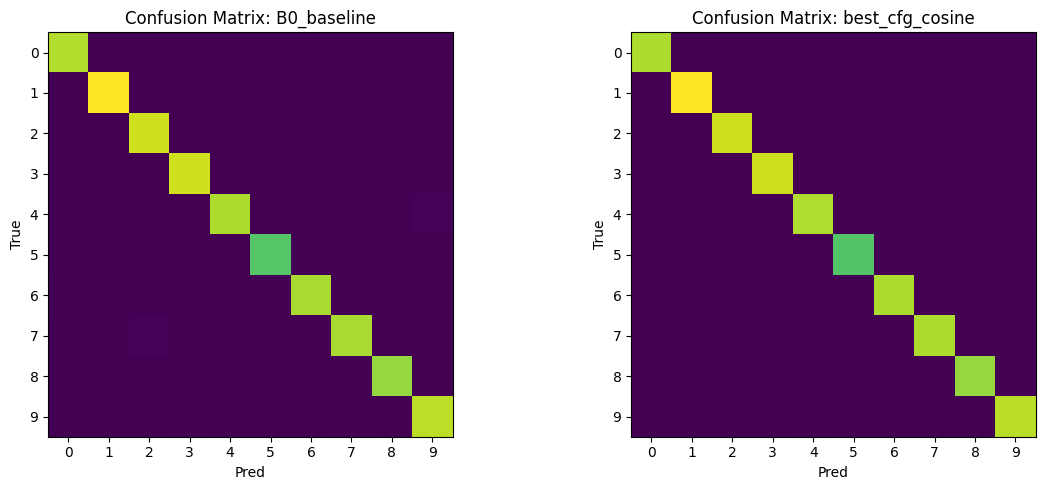

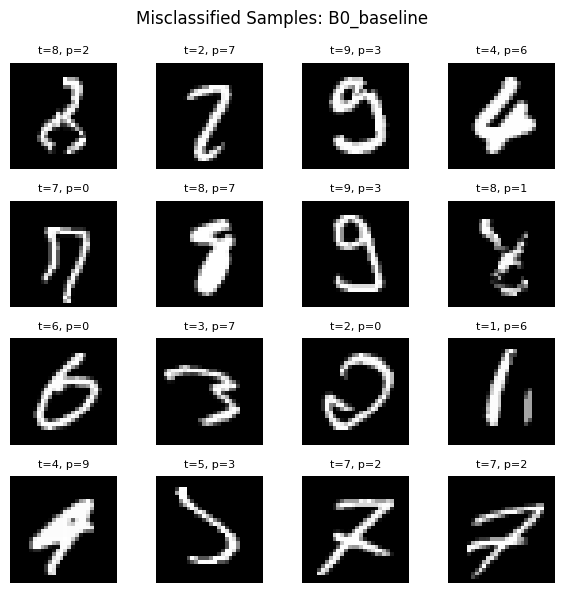

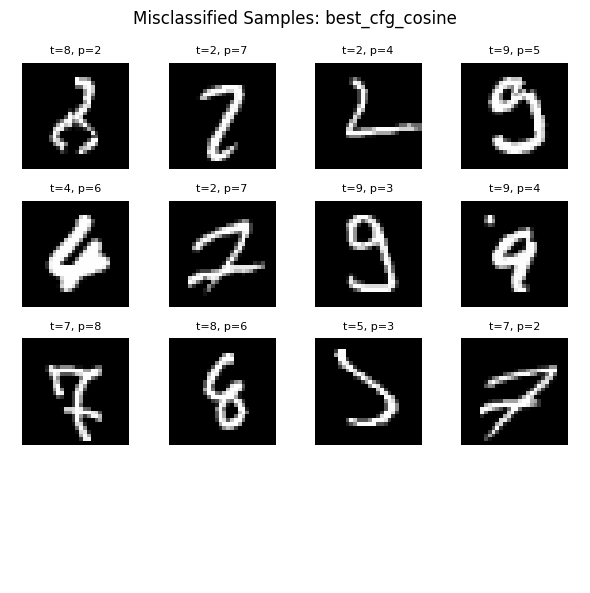

In [77]:
# Optional: confusion matrix + misclassified examples (requires checkpoints + MNIST download)
from sklearn.metrics import confusion_matrix

def eval_predictions(model, loader):
    ys, ps = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            pred = logits.argmax(dim=1).cpu().numpy()
            ys.append(labels.numpy())
            ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)

# Use a manageable subset for speed in notebook
cm_indices = np.random.RandomState(42).choice(len(test_ds), size=min(5000, len(test_ds)), replace=False)
cm_loader = DataLoader(Subset(test_ds, cm_indices), batch_size=256, shuffle=False)

# Compare baseline vs best run (by final_metric)
ranked = final_scores.dropna(subset=["final_metric"]).sort_values("final_metric", ascending=False)
if ranked.empty:
    print("No scored runs available.")
else:
    baseline_run = "B0_baseline"
    best_run = ranked.iloc[0]["run_name"]
    cm_runs = []
    for rn in [baseline_run, best_run]:
        if rn not in cm_runs:
            cm_runs.append(rn)

    fig, axes = plt.subplots(1, len(cm_runs), figsize=(6*len(cm_runs), 5))
    if len(cm_runs) == 1:
        axes = [axes]

    for ax, rn in zip(axes, cm_runs):
        ckpt = f"runs/{rn}.pth"
        if not os.path.exists(ckpt):
            ax.set_title(f"{rn} missing checkpoint")
            ax.axis("off")
            continue
        model = build_model_from_run(rn)
        y_true, y_pred = eval_predictions(model, cm_loader)
        cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
        im = ax.imshow(cm, interpolation="nearest")
        ax.set_title(f"Confusion Matrix: {rn}")
        ax.set_xlabel("Pred")
        ax.set_ylabel("True")
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))
    plt.tight_layout()
    plt.show()

    # Misclassified examples (baseline vs best) on a small subset
    show_n = 16
    viz_loader = DataLoader(Subset(test_ds, cm_indices[:1000]), batch_size=256, shuffle=False)

    def collect_misclassified(model):
        imgs_list, yt_list, yp_list = [], [], []
        with torch.no_grad():
            for imgs, labels in viz_loader:
                imgs = imgs.to(device)
                logits = model(imgs)
                preds = logits.argmax(dim=1).cpu()
                wrong = preds != labels
                if wrong.any():
                    idx = wrong.nonzero(as_tuple=False).squeeze(1)
                    imgs_list.append(imgs.cpu()[idx])
                    yt_list.append(labels[idx])
                    yp_list.append(preds[idx])
                if sum(x.size(0) for x in imgs_list) >= show_n:
                    break
        if not imgs_list:
            return None
        X = torch.cat(imgs_list)[:show_n]
        yt = torch.cat(yt_list)[:show_n]
        yp = torch.cat(yp_list)[:show_n]
        return X, yt, yp

    for rn in cm_runs:
        ckpt = f"runs/{rn}.pth"
        if not os.path.exists(ckpt):
            continue
        model = build_model_from_run(rn)
        out = collect_misclassified(model)
        if out is None:
            print(f"No misclassifications found in sample for {rn}")
            continue
        X, yt, yp = out
        fig, axes = plt.subplots(4, 4, figsize=(6,6))
        axes = axes.flatten()
        n_show = min(show_n, X.size(0))
        for i in range(len(axes)):
            axes[i].axis("off")
        for i in range(n_show):
            img = X[i].squeeze(0).numpy()
            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(f"t={int(yt[i])}, p={int(yp[i])}", fontsize=8)
            axes[i].axis("off")
        fig.suptitle(f"Misclassified Samples: {rn}", fontsize=12)
        plt.tight_layout()
        plt.show()


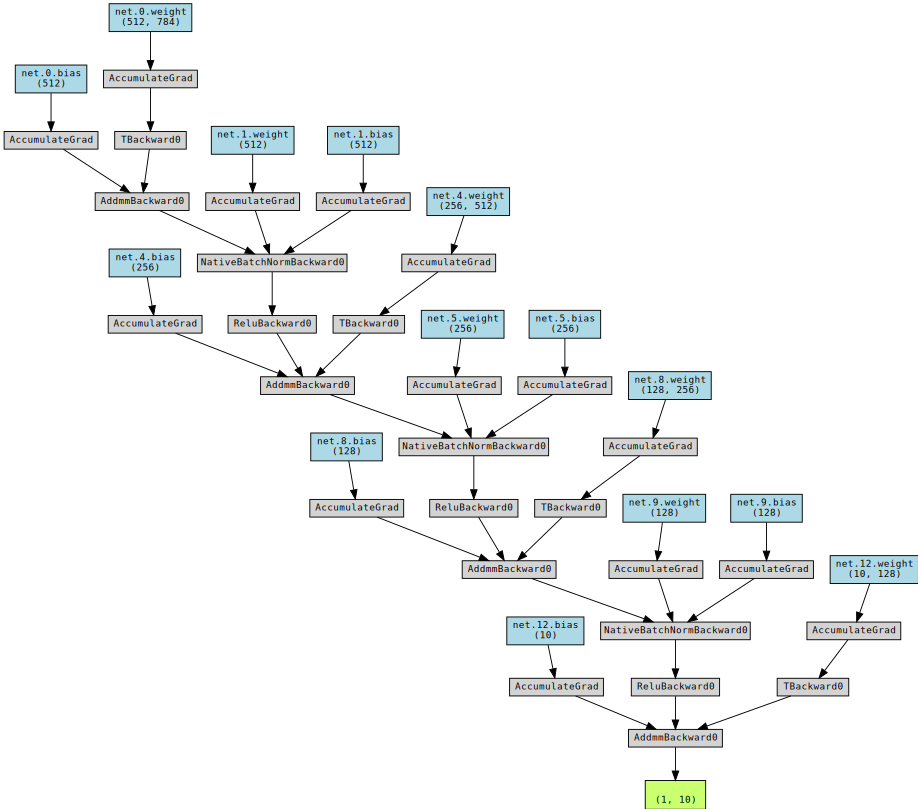

In [78]:
# torchviz for baseline model only (inline display)
try:
    from torchviz import make_dot
    from IPython.display import SVG, display

    baseline_name = "B0_baseline"
    if baseline_name not in set(run_hparams["run_name"]):
        raise ValueError("B0_baseline not found in run_hparams")

    baseline_model = build_model_from_run(baseline_name)
    dummy = torch.randn(1, 1, 28, 28, device=device)
    out = baseline_model(dummy)
    dot = make_dot(out, params=dict(baseline_model.named_parameters()))

    # display graph inline (requires graphviz `dot` installed)
    display(SVG(dot.pipe(format="svg")))
except Exception as e:
    print("torchviz generation skipped:", e)


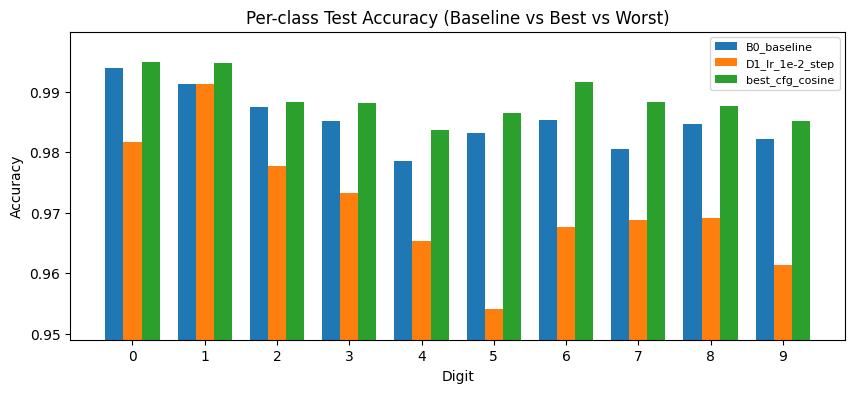

In [79]:
# Per-class accuracy comparison (from logged test_per_class)
def parse_per_class(s):
    if pd.isna(s):
        return None
    parts = [p.strip() for p in str(s).split(",") if p.strip()]
    if len(parts) != 10:
        return None
    return np.array([float(x) for x in parts], dtype=float)

compare_runs = ["B0_baseline"]
ranked = final_scores.dropna(subset=["final_metric"]).sort_values("final_metric", ascending=False)
if not ranked.empty:
    best_run = ranked.iloc[0]["run_name"]
    worst_run = ranked.iloc[-1]["run_name"]
    for rn in [best_run, worst_run]:
        if rn not in compare_runs:
            compare_runs.append(rn)

pc = test_df[test_df["run_name"].isin(compare_runs)].copy()
pc["vec"] = pc["test_per_class"].apply(parse_per_class)
pc = pc[pc["vec"].notna()]

if pc.empty:
    print("No per-class test logs available.")
else:
    digits = np.arange(10)
    plt.figure(figsize=(10,4))
    width = 0.25
    for i, (_, row) in enumerate(pc.iterrows()):
        plt.bar(digits + i*width, row["vec"], width=width, label=row["run_name"])
    plt.xticks(digits + width, [str(d) for d in digits])
    plt.title("Per-class Test Accuracy (Baseline vs Best vs Worst)")
    plt.xlabel("Digit")
    plt.ylabel("Accuracy")
    plt.legend(fontsize=8)
    ax = plt.gca()
    zoom_ylim(ax, np.concatenate(pc["vec"].values), pad=0.005)
    plt.show()


In [80]:
final_scores.sort_values("final_metric", ascending=False).reset_index(drop=True)


,run_name,best_val_acc_so_far,test_acc,test_per_class,hidden_sizes,activation,dropout,use_bn,bn_position,lr,scheduler,step_size,gamma,tmax,weight_decay,l1_lambda,batch_size,epochs,seed,final_metric
0,best_cfg_cosine,0.9890,0.9890,"0.994898,0.994714,0.988372,0.988119,0.983707,0...","512,256,128",relu,0.1,1,pre,0.0010,cosine,5,0.5,10,0.00010,0.000000,64,20,42,0.9890
1,D6_sched_cosine,0.9868,0.9868,"0.991837,0.996476,0.987403,0.986139,0.986762,0...","512,256,128",relu,0.3,1,pre,0.0010,cosine,5,0.5,10,0.00010,0.000000,64,10,42,0.9868
2,C2_drop_0p1,0.9853,0.9853,"0.991837,0.996476,0.986434,0.985149,0.976578,0...","512,256,128",relu,0.1,1,pre,0.0010,step,5,0.5,10,0.00010,0.000000,64,10,42,0.9853
3,F3_l2_1e-4,0.9853,0.9853,"0.993878,0.991189,0.987403,0.985149,0.978615,0...","512,256,128",relu,0.3,1,pre,0.0010,step,5,0.5,10,0.00010,0.000000,64,10,42,0.9853
4,B0_baseline,0.9853,0.9853,"0.993878,0.991189,0.987403,0.985149,0.978615,0...","512,256,128",relu,0.3,1,pre,0.0010,step,5,0.5,10,0.00010,0.000000,64,10,42,0.9853
5,A6_depth3_w512,0.9848,0.9848,"0.990816,0.995595,0.984496,0.991089,0.985743,0...","512,512,512",relu,0.3,1,pre,0.0010,step,5,0.5,10,0.00010,0.000000,64,10,42,0.9848
6,A4_depth4_w256,0.9846,0.9846,"0.991837,0.992070,0.980620,0.986139,0.986762,0...","256,256,256,256",relu,0.3,1,pre,0.0010,step,5,0.5,10,0.00010,0.000000,64,10,42,0.9846
7,B2_act_gelu,0.9845,0.9845,"0.992857,0.996476,0.981589,0.986139,0.971487,0...","512,256,128",gelu,0.3,1,pre,0.0010,step,5,0.5,10,0.00010,0.000000,64,10,42,0.9845
8,F6_l1_1e-5,0.9845,0.9845,"0.991837,0.992070,0.986434,0.989109,0.991853,0...","512,256,128",relu,0.3,1,pre,0.0010,step,5,0.5,10,0.00000,0.000010,64,10,42,0.9845
9,A2_depth2_w256,0.9844,0.9844,"0.994898,0.990308,0.986434,0.980198,0.977597,0...","256,256",relu,0.3,1,pre,0.0010,step,5,0.5,10,0.00010,0.000000,64,10,42,0.9844
